In [1]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

In [3]:
df_2025= pd.read_csv(r"C:\Users\NIKITA\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\F6C45318340BE3F8AD07317BE4406F47842C9B90\transfers\2026-11\2025.csv")
df_2026=pd.read_csv(r"C:\Users\NIKITA\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\F6C45318340BE3F8AD07317BE4406F47842C9B90\transfers\2026-11\2026.csv")

In [4]:
df=pd.concat([df_2025, df_2026])
df.head()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Andhra Pradesh,Chittor,Chittoor,Gur (Jaggery),NO 2,FAQ,2025-01-01,3200.0,3500.0,3500.0,74
1,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Garlic,Average,Local,2025-01-01,28000.0,30000.0,30000.0,25
2,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Ginger (Green),Green Ginger,Local,2025-01-01,7000.0,8000.0,8000.0,103
3,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Green Chilli,Green Chilly,Local,2025-01-01,4500.0,5000.0,5000.0,87
4,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Mint (Pudina),Mint (Pudina),Local,2025-01-01,4500.0,5000.0,5000.0,360


In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 5984442 entries, 0 to 164959
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   State           str    
 1   District        str    
 2   Market          str    
 3   Commodity       str    
 4   Variety         str    
 5   Grade           str    
 6   Arrival_Date    str    
 7   Min_Price       float64
 8   Max_Price       float64
 9   Modal_Price     float64
 10  Commodity_Code  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 547.9 MB


In [11]:
df.describe()

,Min_Price,Max_Price,Modal_Price,Commodity_Code
count,5.984442e+06,5.984442e+06,5.984442e+06,5.984442e+06
mean,4.018470e+03,4.715419e+03,4.481359e+03,1.041750e+02
std,6.081017e+03,7.022458e+03,6.596095e+03,9.569131e+01
min,0.000000e+00,0.000000e+00,5.000000e-02,1.000000e+00
25%,1.850000e+03,2.200000e+03,2.040000e+03,2.400000e+01
50%,3.000000e+03,3.500000e+03,3.400000e+03,8.200000e+01
75%,5.000000e+03,5.800000e+03,5.500000e+03,1.570000e+02
max,4.000000e+06,4.000000e+06,4.000000e+06,4.800000e+02


In [12]:
df["Max_Price"].describe()

count    5.984442e+06
mean     4.715419e+03
std      7.022458e+03
min      0.000000e+00
25%      2.200000e+03
50%      3.500000e+03
75%      5.800000e+03
max      4.000000e+06
Name: Max_Price, dtype: float64

In [13]:
df.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code'],
      dtype='str')

In [14]:
df.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
dtype: int64

In [15]:
df['Arrival_Date'] 
pd.to_datetime(df['Arrival_Date'], errors='coerce')
data = df.sort_values('Arrival_Date')
print(df['Arrival_Date'].min(), df['Arrival_Date'].max())

01-01-2026 31-12-2025


In [16]:
df['Max_Price'].dtype

dtype('float64')

In [17]:
print(f"Minimum Price: {data['Max_Price'].min()}")
print(f"Maximum Price: {data['Max_Price'].max()}")
print(f"Mean Price: {data['Max_Price'].mean():.2f}") # :.2f rounds to 2 decimal places
print(f"First 20 Unique Values: {data['Max_Price'].unique()[:20]}")

print("\nTop 10 Value Counts:")
print(data['Max_Price'].value_counts().head(10))

Minimum Price: 0.0
Maximum Price: 4000000.0
Mean Price: 4715.42
First 20 Unique Values: [ 20000.   2658.   1910.   5110.   1565.   2651.   5000.   4000.   1900.
   2675.   4461.   3000.   7350.    800.   2500.   5500.   6670.   1620.
   5097. 300000.]

Top 10 Value Counts:
Max_Price
3000.0    376343
4000.0    365385
5000.0    271031
2000.0    263667
6000.0    248671
2500.0    221747
3500.0    192125
7000.0    145538
1500.0    135550
8000.0    119154
Name: count, dtype: int64


In [18]:
top_crops = data['Commodity'].value_counts().head(10)
print("Top 10 crops:\n", top_crops)

Top 10 crops:
 Commodity
Onion                     226844
Tomato                    216087
Potato                    209354
Wheat                     193384
Brinjal                   190408
Banana                    181653
Green Chilli              180539
Bhindi (Ladies Finger)    151879
Bottle gourd              140885
Cabbage                   138396
Name: count, dtype: int64


In [19]:
# Strip spaces and convert to datetime safely
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'].astype(str).str.strip(), errors='coerce')

# Check for invalid dates
invalid_dates = df['Arrival_Date'].isna().sum()
print("Number of invalid dates:", invalid_dates)

Number of invalid dates: 164960


In [20]:
df = df[df['Arrival_Date'].dt.year.isin([2025, 2026])]
print("Shape after filtering:", df.shape)

Shape after filtering: (5819482, 11)


In [21]:
df['Year']=df['Arrival_Date'].dt.year
yearly_avg = df.groupby('Year')['Max_Price'].mean()
print(yearly_avg)

Year
2025    4710.026842
Name: Max_Price, dtype: float64


In [22]:
import matplotlib.pyplot as plt


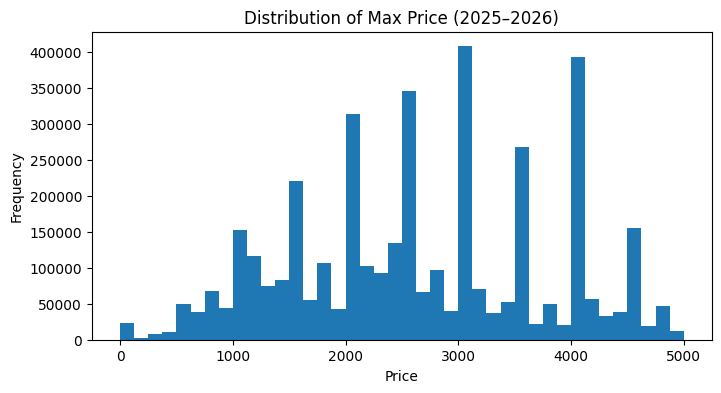

In [23]:
plt.figure(figsize=(8,4))
filtered_data = data[data['Max_Price'] < 5000]
plt.hist(filtered_data['Max_Price'], bins=40)
plt.title("Distribution of Max Price (2025–2026)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

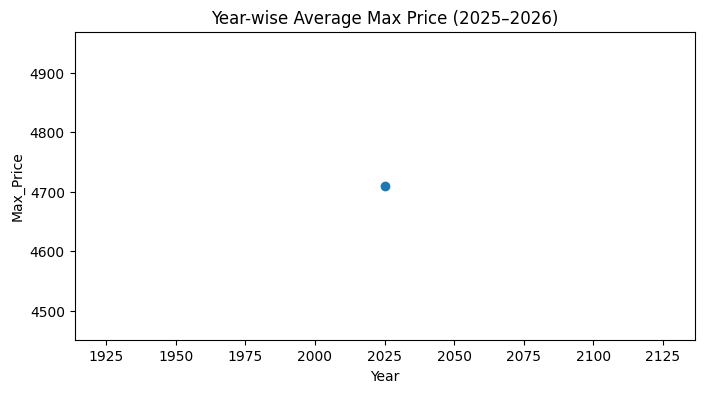

In [24]:
plt.figure(figsize=(8,4))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title("Year-wise Average Max Price (2025–2026)")
plt.xlabel("Year")
plt.ylabel("Max_Price")
plt.show()

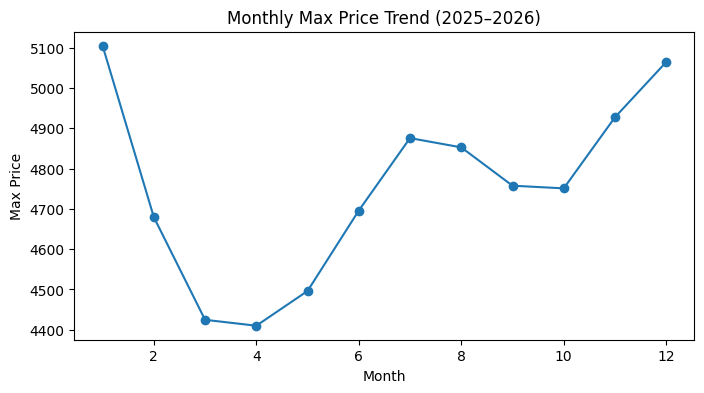

In [25]:
df['month'] = df['Arrival_Date'].dt.month
monthly_avg = df.groupby('month')['Max_Price'].mean()

plt.figure(figsize=(8,4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Monthly Max Price Trend (2025–2026)")
plt.xlabel("Month")
plt.ylabel("Max Price")
plt.show()

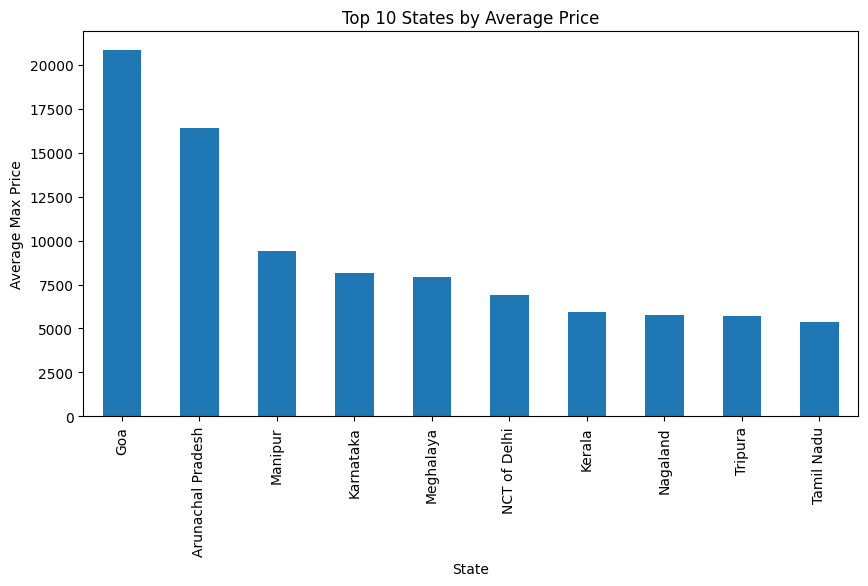

In [26]:
state_avg = df.groupby('State')['Max_Price'].mean().sort_values(ascending=False)
state_avg.head(10).plot(kind='bar', figsize=(10,5), title="Top 10 States by Average Price")
plt.xlabel("State")
plt.ylabel("Average Max Price")
plt.show()

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_2025 = pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\christ\2025.csv")
df_2026 = pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\christ\2026.csv")

In [3]:
df = pd.concat([df_2025, df_2026])
df.head()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Andhra Pradesh,Chittor,Chittoor,Gur (Jaggery),NO 2,FAQ,2025-01-01,3200.0,3500.0,3500.0,74
1,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Garlic,Average,Local,2025-01-01,28000.0,30000.0,30000.0,25
2,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Ginger (Green),Green Ginger,Local,2025-01-01,7000.0,8000.0,8000.0,103
3,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Green Chilli,Green Chilly,Local,2025-01-01,4500.0,5000.0,5000.0,87
4,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Mint (Pudina),Mint (Pudina),Local,2025-01-01,4500.0,5000.0,5000.0,360


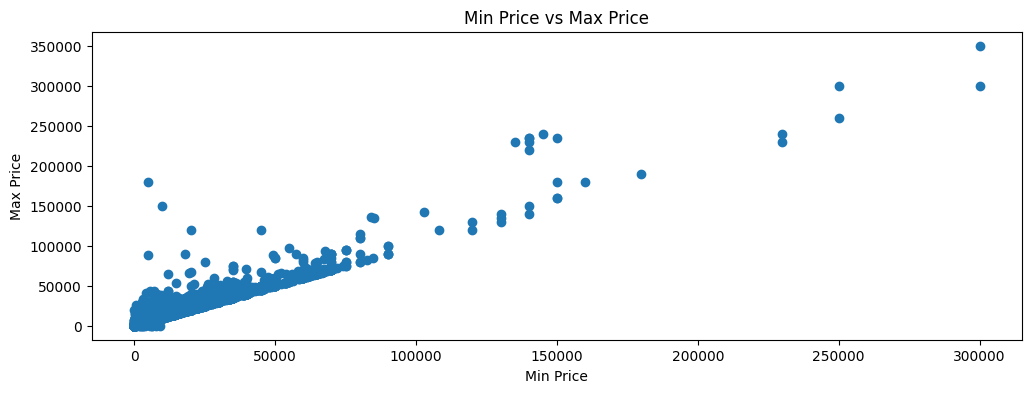

In [28]:
sample = df.sample(100000)

plt.figure(figsize=(12,4))
plt.scatter(sample['Min_Price'], sample['Max_Price'])
plt.xlabel("Min Price")
plt.ylabel("Max Price")
plt.title("Min Price vs Max Price")
plt.show()

C:\Users\Anushka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


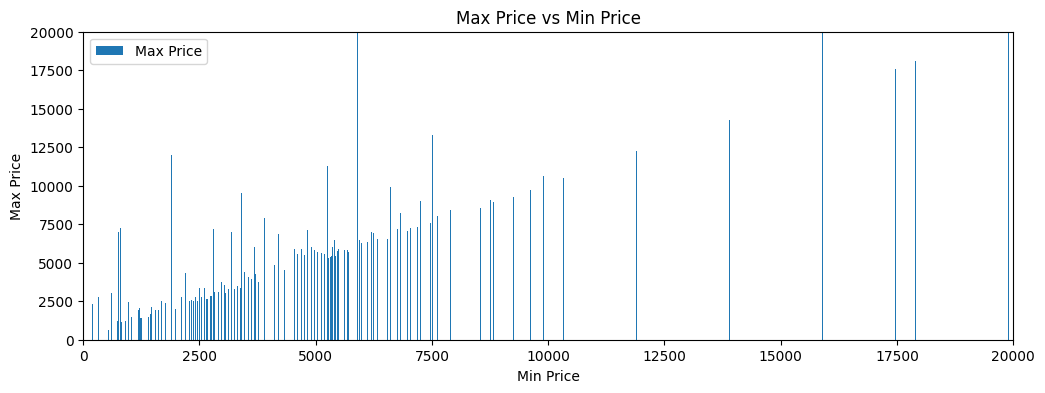

In [29]:
sample = df.sample(100000)

plt.figure(figsize=(12,4))
plt.bar(sample['Min_Price'], sample['Max_Price'], label='Max Price')
plt.xlim(0, 20000)
plt.ylim(0,20000)
plt.xlabel("Min Price")
plt.ylabel("Max Price")
plt.title("Max Price vs Min Price")

plt.legend()
plt.show()

In [4]:
df.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
dtype: int64

In [5]:
df.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code'],
      dtype='str')

In [6]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Clean the data
df_final = df.dropna(subset=['Max_Price']).copy()

# 2. Use LabelEncoder for all text columns
# We save the encoders in a dictionary so we can use them in Gradio later
encoders = {}
categorical_cols = ['State', 'District', 'Market', 'Commodity', 'Variety']

for col in categorical_cols:
    le = LabelEncoder()
    # Convert to string to avoid errors with mixed types/NaNs
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    encoders[col] = le 

# 3. Define X and y (Using only the columns you want for prediction)
X = df_final[categorical_cols + ['Min_Price', 'Modal_Price']]
y = df_final['Max_Price']

# 4. Fit the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

print("Model trained successfully with Label Encoding!")

Model trained successfully with Label Encoding!


In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101
)

In [9]:
from sklearn.linear_model import LinearRegression
df_encoded = pd.get_dummies(df, columns=['State'])
y = df_encoded['Max_Price']
X = df_encoded.drop('Max_Price', axis=1)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred = model.predict(X_test)
y_pred

array([  651.32123706, 10745.18347228,  7915.25007347, ...,
        6780.60925317,  2945.2889078 ,  3993.75217715], shape=(1196889,))

In [11]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.9750309531635863


In [12]:
print("R2 score: ",r2_score(y_test, y_pred))

R2 score:  0.9750309531635863


In [13]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
1199730,800.0,651.321237
5781435,11000.0,10745.183472
4064288,8000.0,7915.250073
5249389,2500.0,2448.713069
2306135,9.0,131.805688


In [7]:
dataset_2025= pd.read_csv(r"C:\Users\Anushka\Desktop\2025.csv")
dataset_2026= pd.read_csv(r"C:\Users\Anushka\Desktop\2026.csv")

In [14]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import gradio as gr
import numpy as np

c:\Users\NIKITA\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:


def predict_max_price(state, district, market, commodity, variety, min_price, modal_price):
    # 1. Prepare input list for categorical columns
    inputs = {
        'State': state,
        'District': district,
        'Market': market,
        'Commodity': commodity,
        'Variety': variety
    }
    
    # 2. Encode categorical inputs using the encoders saved during training
    encoded_values = []
    for col in categorical_cols:
        le = encoders[col]
        val = str(inputs[col])
        # Note: If user types something the model hasn't seen, 
        # this will throw an error. In a production app, you'd add a try/except.
        encoded_values.append(le.transform([val])[0])
    
    # 3. Combine with numerical inputs
    final_features = encoded_values + [min_price, modal_price]
    
    # 4. Predict
    prediction = model.predict([final_features])
    
    return f"Predicted Maximum Price: {round(prediction[0], 2)}"

# Define the UI
interface = gr.Interface(
    fn=predict_max_price,
    inputs=[
        gr.Dropdown(choices=list(encoders['State'].classes_), label="State"),
        gr.Dropdown(choices=list(encoders['District'].classes_), label="District"),
        gr.Dropdown(choices=list(encoders['Market'].classes_), label="Market"),
        gr.Dropdown(choices=list(encoders['Commodity'].classes_), label="Commodity"),
        gr.Dropdown(choices=list(encoders['Variety'].classes_), label="Variety"),
        gr.Number(label="Min Price"),
        gr.Number(label="Modal Price")
    ],
    outputs="text",
    title="MAXIMUM CROP PRICE PREDICTOR ",
    description="Enter the details below to predict the Maximum Price."
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [ ]:
import gradio as gr

# Setup a clean, modern theme
theme = gr.themes.Soft(primary_hue="emerald", secondary_hue="slate")

with gr.Blocks(theme=theme) as demo:
    gr.Markdown("# 🌾 Agricultural Price Predictor")
    gr.Markdown("Fill in the details below to estimate the **Maximum Price** based on historical trends.")
    
    with gr.Row():
        # Column 1: Geographic Data
        with gr.Column():
            gr.Markdown("### 📍 Location Details")
            state = gr.Dropdown(choices=list(encoders['State'].classes_), label="State")
            district = gr.Dropdown(choices=list(encoders['District'].classes_), label="District")
            market = gr.Dropdown(choices=list(encoders['Market'].classes_), label="Market")

        # Column 2: Commodity Data
        with gr.Column():
            gr.Markdown("### 🍎 Product Details")
            commodity = gr.Dropdown(choices=list(encoders['Commodity'].classes_), label="Commodity")
            variety = gr.Dropdown(choices=list(encoders['Variety'].classes_), label="Variety")
            
        # Column 3: Price Inputs & Output
        with gr.Column():
            gr.Markdown("### 💰 Price Benchmarks")
            min_p = gr.Number(label="Min Price (Current)", value=0)
            mod_p = gr.Number(label="Modal Price (Current)", value=0)
            
            predict_btn = gr.Button("Calculate Prediction", variant="primary")
            output_text = gr.Textbox(label="Result", placeholder="Waiting for input...")

    # Define the logic (using the function from the previous step)
    predict_btn.click(
        fn=predict_max_price, 
        inputs=[state, district, market, commodity, variety, min_p, mod_p], 
        outputs=output_text
    )
    
    # Optional: Add examples at the bottom so users can test it instantly
    gr.Examples(
        examples=[
            ["Punjab", "Amritsar", "Amritsar", "Wheat", "Other", 2100, 2250],
            ["Haryana", "Karnal", "Karnal", "Rice", "Basmati", 3500, 4000]
        ],
        inputs=[state, district, market, commodity, variety, min_p, mod_p]
    )

demo.launch(server_port=7862)

C:\Users\pc\AppData\Local\Temp\ipykernel_15056\1214915835.py:6: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=theme) as demo:
c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\components\dropdown.py:235: UserWarning: The value passed into gr.Dropdown() is not in the list of choices. Please update the list of choices to include: Karnal or set allow_custom_value=True.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
import pickle 
with open('max_price.pkl', 'wb') as f:
    pickle.dump(model,f)

In [17]:
import pickle

# Save these once. They will be shared by all 3 models.
pickle.dump(le, open('le_state.pkl', 'wb'))
pickle.dump(le, open('le_district.pkl', 'wb'))
pickle.dump(le, open('le_commodity.pkl', 'wb'))